<a href="https://colab.research.google.com/github/shehanidilmi52-ctrl/NorthStar-Analytics/blob/main/02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
install.packages("sqldf", quiet=TRUE)
install.packages("ggplot2", quiet=TRUE)
library(sqldf)
library(ggplot2)

base_url <- "https://raw.githubusercontent.com/shehanidilmi52-ctrl/NorthStar-Analytics/main/"

drivers    <- read.csv(url(paste0(base_url, "drivers.csv")))
orders     <- read.csv(url(paste0(base_url, "orders.csv")))
deliveries <- read.csv(url(paste0(base_url, "deliveries.csv")))
complaints <- read.csv(url(paste0(base_url, "complaints.csv")))
vehicles   <- read.csv(url(paste0(base_url, "vehicles.csv")))
customers  <- read.csv(url(paste0(base_url, "customers.csv")))
incidents  <- read.csv(url(paste0(base_url, "incidents.csv")))
hubs       <- read.csv(url(paste0(base_url, "hubs.csv")))

cat("✅ All files loaded from GitHub!\n")

✅ All files loaded from GitHub!


In [ ]:
path <- '/content/'

drivers <- read.csv(paste0(path, 'drivers.csv'))
orders <- read.csv(paste0(path, 'orders.csv'))
deliveries <- read.csv(paste0(path, 'deliveries.csv'))
complaints <- read.csv(paste0(path, 'complaints.csv'))
vehicles <- read.csv(paste0(path, 'vehicles.csv'))
customers <- read.csv(paste0(path, 'customers.csv'))
incidents <- read.csv(paste0(path, 'incidents.csv'))
hubs <- read.csv(paste0(path, 'hubs.csv'))

cat("✅ All files loaded!\n")

✅ All files loaded!


In [ ]:
cat("=== DELIVERY STATISTICS ===\n")
cat("Average fuel cost:", mean(deliveries$fuel_or_charge_cost), "\n")
cat("Average customer rating:", mean(deliveries$customer_rating_post_delivery), "\n")
cat("Average route distance:", mean(deliveries$route_distance_km), "\n")

cat("\n=== COMPLAINTS STATISTICS ===\n")
cat("Average resolution days:", mean(complaints$resolution_days), "\n")
cat("Average compensation:", mean(complaints$compensation_amount), "\n")

cat("\n=== DRIVER STATISTICS ===\n")
cat("Average driver rating:", mean(drivers$driver_rating), "\n")
cat("Average years experience:", mean(drivers$years_experience), "\n")

=== DELIVERY STATISTICS ===
Average fuel cost: 12.84129 
Average customer rating: NA 
Average route distance: 13.90932 

=== COMPLAINTS STATISTICS ===
Average resolution days: 7.928125 
Average compensation: NA 

=== DRIVER STATISTICS ===
Average driver rating: 4.171706 
Average years experience: 8.223529 


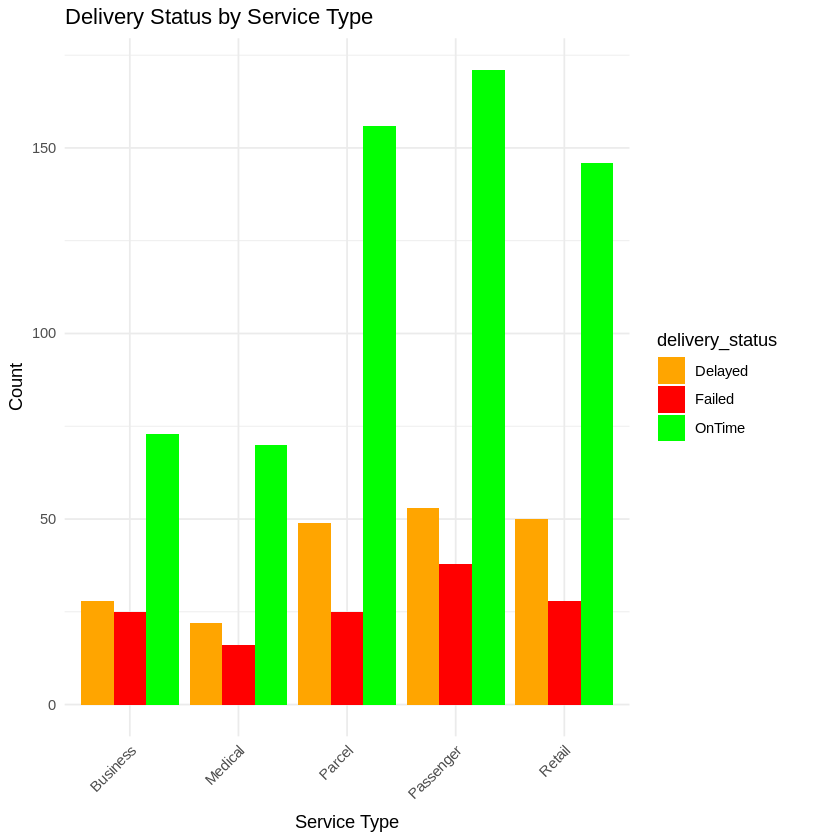

In [ ]:
merged <- merge(deliveries, orders, by="order_id")

ggplot(merged, aes(x=service_type, fill=delivery_status)) +
  geom_bar(position="dodge") +
  scale_fill_manual(values=c('OnTime'='green', 'Delayed'='orange', 'Failed'='red')) +
  labs(title='Delivery Status by Service Type',
       x='Service Type', y='Count') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))

`geom_smooth()` using formula = 'y ~ x'


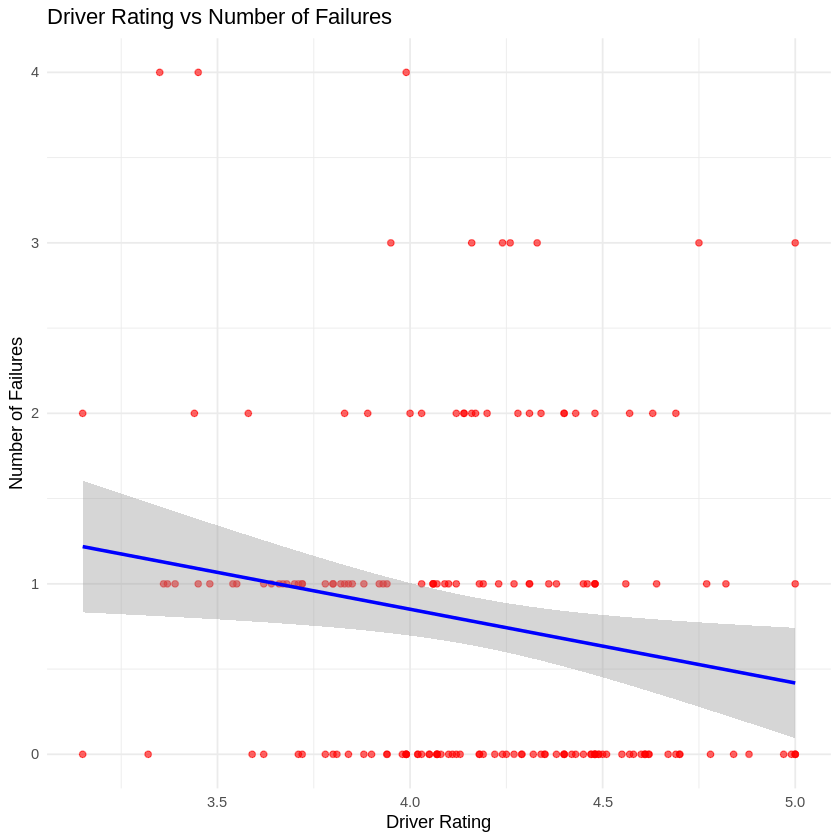

In [ ]:
driver_perf <- merge(deliveries, drivers, by="driver_id")
driver_summary <- aggregate(
  cbind(failures=delivery_status=="Failed") ~ driver_id + driver_rating,
  data=driver_perf,
  FUN=sum
)

ggplot(driver_summary, aes(x=driver_rating, y=failures)) +
  geom_point(color='red', alpha=0.6) +
  geom_smooth(method='lm', color='blue') +
  labs(title='Driver Rating vs Number of Failures',
       x='Driver Rating', y='Number of Failures') +
  theme_minimal()

In [ ]:
ggplot(complaints, aes(x=severity, fill=complaint_type)) +
  geom_bar(position="stack") +
  labs(title='Complaints by Severity and Type',
       x='Severity', y='Count') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))

In [ ]:
veh_del <- merge(deliveries, vehicles, by="vehicle_id")

ggplot(veh_del, aes(x=battery_health_pct, fill=delivery_status)) +
  geom_histogram(bins=20, position="dodge") +
  scale_fill_manual(values=c('OnTime'='green', 'Delayed'='orange', 'Failed'='red')) +
  labs(title='Battery Health vs Delivery Status',
       x='Battery Health %', y='Count') +
  theme_minimal()

ERROR: Error in ggplot(veh_del, aes(x = battery_health_pct, fill = delivery_status)): could not find function "ggplot"


In [ ]:
ggplot(complaints, aes(x=complaint_type, y=resolution_days, fill=complaint_type)) +
  geom_boxplot() +
  labs(title='Resolution Days by Complaint Type',
       x='Complaint Type', y='Days to Resolve') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))

In [ ]:
cust_orders <- merge(customers, orders, by="customer_id")

ggplot(cust_orders, aes(x=loyalty_score, y=order_value)) +
  geom_point(color='blue', alpha=0.5) +
  geom_smooth(method='lm', color='red') +
  labs(title='Customer Loyalty Score vs Order Value',
       x='Loyalty Score', y='Order Value') +
  theme_minimal()

In [ ]:
ggplot(incidents, aes(x=incident_type, fill=resolution_status)) +
  geom_bar(position="dodge") +
  labs(title='Incidents by Type and Resolution Status',
       x='Incident Type', y='Count') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))